In [88]:
import torch
import torch.nn as nn

# --- 1. Define Physical Constants ---
L_physical = 8.0  # meters
E = 210e9  # Pa (Young's modulus)
I = 1/12  # m^4 (Moment of inertia for a 1m x 1m cross-section)
d_0_physical = 10.0  # N/m (distributed load)

# --- NORMALIZATION (KEY FIX) ---
# This section non-dimensionalizes the problem.
# This is a critical step to prevent numerical instability, as the
# physical values (like EI) are extremely large, leading to
# exploding or vanishing gradients.

L_norm = 1.0  # We will solve the problem on the normalized domain [0, 1]
x_scale = L_physical # Relationship: x_physical = x_norm * x_scale
EI_physical = E * I

# Choose a characteristic scale for deflection.
# This specific choice, w_char = q*L^4/(EI), is a key part of the
# non-dimensionalization.
d_scale = abs(d_0_physical) * L_physical**4 / EI_physical

# Define normalized parameters.
# Because of our choice of d_scale, the normalized physics
# equation (d_norm'''') will be equal to 1.0.
EI_norm = 1.0  # This becomes 1 after normalization
d_0_norm = 1.0  # This becomes 1 after normalization

print(f"Normalization scales:")
print(f"  x_scale = {x_scale} m")
print(f"  d_scale = {d_scale:.6e} m")
print(f"  EI_physical = {EI_physical:.6e} N⋅m²")
print()

# --- Hyperparameters ---
N_f = 100 # Number of physics collocation points (sampled from the domain)
adam_steps = 5000 # Number of steps for the first-pass optimizer
lr = 1e-3 # Learning rate for Adam
weight_bc = 10  # Weighting factor for the boundary condition loss
weight_physics = 1 # Weighting factor for the physics (PDE) loss

# --- Define PINN Model ---
class PINN(nn.Module):
    """
    Defines the Physics-Informed Neural Network.
    This is a simple Multi-Layer Perceptron (MLP) that will
    approximate the deflection function d(x).
    """
    def __init__(self, hidden_layers=4, neurons_per_layer=32):
        super(PINN, self).__init__()

        # Create the input layer
        layers = [nn.Linear(1, neurons_per_layer), nn.Tanh()]

        # Create the hidden layers
        for _ in range(hidden_layers - 1):
            layers.extend([nn.Linear(neurons_per_layer, neurons_per_layer), nn.Tanh()])

        # Create the output layer
        layers.append(nn.Linear(neurons_per_layer, 1))

        # Combine all layers into a sequential model
        self.net = nn.Sequential(*layers)
        
        # Xavier initialization for better convergence
        # This helps prevent gradients from vanishing or exploding
        # during the start of training.
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        """
        Forward pass of the network.
        Input x is normalized position (x_norm), output is normalized
        deflection (d_norm).
        """
        return self.net(x)

# --- Initialize model and optimizers ---
model = PINN(hidden_layers=5, neurons_per_layer=64)
optimizer_adam = torch.optim.Adam(model.parameters(), lr=lr)

# L-BFGS is a second-order optimizer, often used for fine-tuning
# after Adam gets close to a solution.
optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(), 
    lr=1.0,  # L-BFGS learning rate
    max_iter=20, # Max iterations *per step*
    tolerance_grad=1e-7,
    tolerance_change=1e-9,
    history_size=50,
    line_search_fn="strong_wolfe" # A robust line search algorithm
)

# --- Loss Function (Normalized Equations) ---
def get_loss():
    """
    Calculates the total loss for the PINN.
    This is the core of the method, combining boundary
    condition loss and physics loss.
    """
    
    # Create fresh collocation points each time to maintain gradient graph
    # These tensors must be re-created in each step to avoid
    # PyTorch's "trying to backward through the graph a second time" error.
    x_bc_0 = torch.tensor([[0.0]], requires_grad=True)
    x_bc_1 = torch.tensor([[L_norm]], requires_grad=True)
    
    # Use fixed seed for physics points to ensure consistency
    # This makes training reproducible by sampling the same
    # N_f random points at each step.
    torch.manual_seed(42)
    x_physics = torch.rand(N_f, 1, requires_grad=True)
    # Boundary conditions at x=0
    d_0 = model(x_bc_0) # Deflection d(0)
    # d'(0) - Slope at x=0
    d_x_0 = torch.autograd.grad(d_0, x_bc_0, torch.ones_like(d_0), create_graph=True)[0]
    
    # Boundary conditions at x=L
    d_1 = model(x_bc_1) # Deflection d(L)
    # d'(L) - Slope at x=L
    d_x_1 = torch.autograd.grad(d_1, x_bc_1, torch.ones_like(d_1), create_graph=True)[0]
    # d''(L) - Moment at x=L
    d_xx_1 = torch.autograd.grad(d_x_1, x_bc_1, torch.ones_like(d_x_1), create_graph=True)[0]
    # d'''(L) - Shear at x=L
    d_xxx_1 = torch.autograd.grad(d_xx_1, x_bc_1, torch.ones_like(d_xx_1), create_graph=True)[0]
    
    # BC Loss (normalized - all should be ~0)
    # Cantilever beam: clamped at x=0, free at x=L
    # At x=0: d(0) = 0 (no deflection), d'(0) = 0 (no rotation)
    # At x=L: d''(L) = 0 (no moment), d'''(L) = 0 (no shear)
    loss_bc_1 = d_0**2  # d(0) = 0
    loss_bc_2 = d_x_0**2  # d'(0) = 0 (clamped - no rotation)
    loss_bc_3 = d_xx_1**2  # d''(L) = 0 (free end - no moment)
    loss_bc_4 = d_xxx_1**2  # d'''(L) = 0 (free end - no shear)
    
    L_bc = (loss_bc_1 + loss_bc_2 + loss_bc_3 + loss_bc_4)
    
    # Physics Loss (Euler-Bernoulli: EI*d'''' = w)
    # In normalized form: d'''' = w_norm (since EI_norm = 1, d_norm = 1)
    # retain_graph=True is necessary here because the graph
    # is re-used by L_total.backward().
    d_p = model(x_physics)
    d_p_x = torch.autograd.grad(d_p, x_physics, torch.ones_like(d_p), create_graph=True, retain_graph=True)[0]
    d_p_xx = torch.autograd.grad(d_p_x, x_physics, torch.ones_like(d_p_x), create_graph=True, retain_graph=True)[0]
    d_p_xxx = torch.autograd.grad(d_p_xx, x_physics, torch.ones_like(d_p_xx), create_graph=True, retain_graph=True)[0]
    d_p_xxxx = torch.autograd.grad(d_p_xxx, x_physics, torch.ones_like(d_p_xxx), create_graph=True, retain_graph=True)[0]
    
    # Normalized equation: d'''' = w/(EI) in normalized coordinates
    # The PDE is: EI * d^4d/dx^4 = w
    # In normalized coords where x_norm = x_phys/L: d/dx_phys = (1/L)*d/dx_norm
    # So: d^4/dx_phys^4 = (1/L^4)*d^4/dx_norm^4
    # Therefore: EI * (1/L^4) * d_norm'''' * (d_scale) = w_0
    # Simplifying: d_norm'''' = (w0 * L^4) / (EI * d_scale)
    # Since d_scale = w_0*L^4/EI, this becomes: d_norm'''' = 1.0
    f_residual = d_p_xxxx - 1.0
    # The physics loss is the mean squared error of this residual
    L_physics = torch.mean(f_residual**2)
    
    # Total Loss
    L_total = (weight_bc * L_bc) + (weight_physics * L_physics)
    
    return L_total, L_bc, L_physics

# --- Phase 1: Adam Optimizer ---
print("--- Starting Phase 1: Adam Optimizer ---")
model.train() # Set the model to training mode

for i in range(adam_steps):
    optimizer_adam.zero_grad() # Clear gradients from previous step
    
    L_total, L_bc_unweighted, L_physics_unweighted = get_loss()
    
    # Check for NaN (loss explosion)
    if torch.isnan(L_total):
        print(f"NaN detected at step {i}! Stopping Adam.")
        break
    
    L_total.backward() # Perform backpropagation
    
    # Gradient clipping for stability
    # This prevents gradients from becoming too large,
    # which can cause instability ('nan' values).
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    optimizer_adam.step() # Update model weights
    
    if i % 1000 == 0:
        print(f"Step {i:5d} | Loss: {L_total.item():.6e} | BC: {L_bc_unweighted.item():.6e} | Physics: {L_physics_unweighted.item():.6e}")

print("Adam finished.\n")

# --- Phase 2: L-BFGS Optimizer ---
print("--- Starting Phase 2: L-BFGS Optimizer ---")
lbfgs_step = 0

def lbfgs_closure():
    """
    This function is required by the L-BFGS optimizer.
    It re-evaluates the loss and gradients at each step
    of the optimizer's internal loop.
    """
    global lbfgs_step # Use a global step counter for printing
    optimizer_lbfgs.zero_grad()
    
    L_total, L_bc_unweighted, L_physics_unweighted = get_loss()
    
    # Check for NaN
    if torch.isnan(L_total):
        print(f"NaN detected at L-BFGS step {lbfgs_step}!")
        return L_total
    
    L_total.backward() # Backpropagate
    
    # Gradient clipping (also good practice for L-BFGS)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    if lbfgs_step % 10 == 0:
        print(f"Step {lbfgs_step:5d} | Loss: {L_total.item():.6e} | BC: {L_bc_unweighted.item():.6e} | Physics: {L_physics_unweighted.item():.6e}")
    
    lbfgs_step += 1
    
    return L_total

# Run L-BFGS
model.train()
try:
     # optimizer.step() is the only call needed for L-BFGS.
    # It will call the 'lbfgs_closure' function repeatedly
    # until convergence (or max_iter is reached).
    optimizer_lbfgs.step(lbfgs_closure)
    print("\nL-BFGS completed successfully!")
except RuntimeError as e:
    print(f"\nL-BFGS encountered an error (can be safely ignored if training converged): {e}")

print("\nTraining finished.")

# --- Test the solution ---
print("\n--- Testing Solution ---")
model.eval() # Set model to evaluation mode (disables dropout, etc.)
with torch.no_grad(): # Disables gradient calculation for inference
    # Test at 5 points (0, 0.25, 0.5, 0.75, 1.0)
    x_test = torch.linspace(0, 1, 5).view(-1, 1)
    d_test = model(x_test)
    
    print("Normalized deflection at test points:")
    for i, (x, d) in enumerate(zip(x_test, d_test)):
        # Convert back to physical units for reporting
        x_phys = x.item() * x_scale
        d_phys = d.item() * d_scale
        print(f"  x = {x_phys:.2f} m: d = {d_phys:.6e} m (normalized: {d.item():.6f})")
    
    # Expected tip deflection for cantilever beam with uniform load:
    # w(L) = q*L^4/(8*EI) for uniformly distributed load
    # Note: q_0 is negative (downward), so deflection is downward (negative)
    d_tip_expected = d_0_physical * L_physical**4 / (8 * EI_physical)
    d_tip_computed = d_test[-1].item() * d_scale
    print(f"\nExpected tip deflection: {d_tip_expected:.6e} m")
    print(f"Computed tip deflection: {d_tip_computed:.6e} m")
    print(f"Relative error: {abs(d_tip_computed - d_tip_expected)/abs(d_tip_expected) * 100:.2f}%")

Normalization scales:
  x_scale = 8.0 m
  d_scale = 2.340571e-06 m
  EI_physical = 1.750000e+10 N⋅m²

--- Starting Phase 1: Adam Optimizer ---
Step     0 | Loss: 1.056969e+00 | BC: 5.750656e-04 | Physics: 1.051219e+00
Step  1000 | Loss: 3.653342e-03 | BC: 2.903480e-04 | Physics: 7.498619e-04
Step  2000 | Loss: 2.027045e-03 | BC: 1.135081e-04 | Physics: 8.919641e-04
Step  3000 | Loss: 5.111345e-05 | BC: 2.293364e-06 | Physics: 2.817981e-05
Step  4000 | Loss: 4.170123e-04 | BC: 3.119124e-05 | Physics: 1.050999e-04
Adam finished.

--- Starting Phase 2: L-BFGS Optimizer ---
Step     0 | Loss: 3.384357e-05 | BC: 1.442954e-06 | Physics: 1.941403e-05
Step    10 | Loss: 1.226688e-05 | BC: 5.819433e-09 | Physics: 1.220869e-05
Step    20 | Loss: 1.009066e-05 | BC: 4.936474e-09 | Physics: 1.004129e-05

L-BFGS completed successfully!

Training finished.

--- Testing Solution ---
Normalized deflection at test points:
  x = 0.00 m: d = 3.658709e-10 m (normalized: 0.000156)
  x = 2.00 m: d = 3.127167

Loading FEA data from 'calculix_results.dat'...
FEA data loaded successfully.


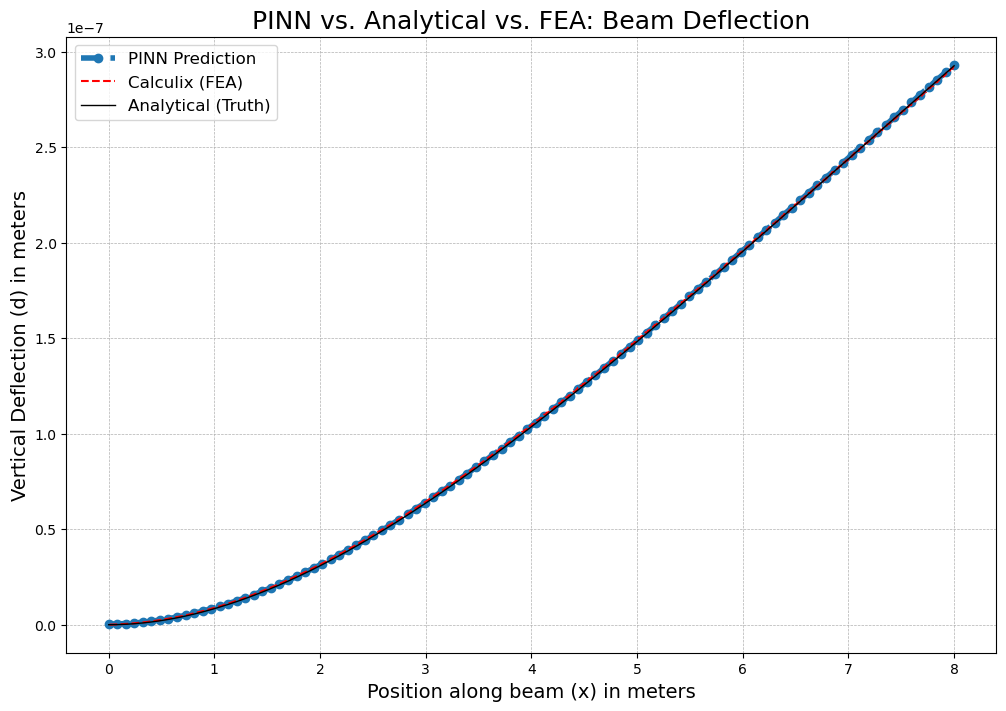

In [99]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Re-define Constants (Must match your training script!) ---
# These constants are needed to convert the normalized
# results back to physical units for plotting.

L_physical = 8.0  # meters
E = 210e9  # Pa
I = 1/12  # m^4
d_0_physical = 10.0  # N/m (Your positive (upward) load)
EI_physical = E * I

# Re-define the exact scaling factors from your script
x_scale = L_physical
d_scale = abs(d_0_physical) * L_physical**4 / EI_physical

# --- 2. Generate Test Points ---
# Create 100 points in the NORMALIZED domain [0, 1]
x_test_norm_np = np.linspace(0, 1, 100)
x_test_norm_torch = torch.tensor(x_test_norm_np, dtype=torch.float32).view(-1, 1)

# --- 3. Get PINN Prediction (and convert to physical units) ---
# Ensure 'model' is the trained model from your previous cell
model.eval()  # Set model to evaluation mode
with torch.no_grad():
    # Get normalized prediction from the model
    d_pinn_norm = model(x_test_norm_torch)
    
    # Convert the normalized output back to physical deflection
    d_pinn_phys = d_pinn_norm.numpy() * d_scale

# Get the corresponding physical x-coordinates for plotting
x_test_phys = x_test_norm_np * x_scale

# --- 4. Get Analytical "Ground Truth" (in physical units) ---
# This is the textbook solution for the physical problem
# d(x) = (q*x^2)/(24*EI) * (x^2 - 4Lx + 6L^2)
x_phys = x_test_phys
L = L_physical
EI = EI_physical
q = d_0_physical 

d_truth_phys = (q * x_phys**2) / (24 * EI) * (x_phys**2 - 4*L*x_phys + 6*L**2)


# --- 5. Load Your Calculix (FEA) Data ---
# This section loads the file 'calculix_results.dat'
try:
    print("Loading FEA data from 'calculix_results.dat'...")
    # Load the text file, skipping the first 2 header lines
    fea_data = np.loadtxt('calculix_results.dat', skiprows=2)
    
    # Your data is in (Deflection, Position) format
    # Column 0 is Deflection (d)
    # Column 1 is Position (x)
    d_fea_phys = fea_data[:, 0]
    x_fea_phys = fea_data[:, 1]
    print("FEA data loaded successfully.")

except IOError:
    print("--- ERROR ---")
    print("'calculix_results.dat' file not found.")
    print("Please save your data to that file in the same directory.")
    # Create empty arrays so the plot still runs (but shows no FEA)
    x_fea_phys = np.array([])
    d_fea_phys = np.array([])
# --- End of Data Loading Section ---

# --- 6. Plot the 3-Way Comparison ---
plt.figure(figsize=(12, 8))



# Plot the PINN Prediction as a dashed red line
plt.plot(x_test_phys, d_pinn_phys, 'o--', label=f'PINN Prediction', linewidth=4)

# Plot the Calculix (FEA) data as blue circles
plt.plot(x_fea_phys, d_fea_phys, 'r--', label='Calculix (FEA)', markersize=1)

# Plot the Analytical "Truth" as a solid black line
plt.plot(x_test_phys, d_truth_phys, 'k-', label=f'Analytical (Truth)', linewidth=1)

plt.title('PINN vs. Analytical vs. FEA: Beam Deflection', fontsize=18)
plt.xlabel('Position along beam (x) in meters', fontsize=14)
plt.ylabel('Vertical Deflection (d) in meters', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Format the y-axis to use scientific notation (since numbers are small)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.show()